In [33]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import polars as pl
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib as mpl
import numpy as np

plt.style.use(['science', 'ieee'])
con = duckdb.connect(database = 'results.db', read_only = False)

output = widgets.Output()

plt.rcParams.update({'font.size': 18})
plt.rcParams['axes.prop_cycle'] = mpl.cycler('linestyle', ['-', '--', ':', '-.']) + mpl.cycler('color', ['b', 'r', 'g', 'm'])

In [29]:
query = """
SELECT TIME, MEAN("PUBLISHER BITRATE") AS "Publisher bitrate" FROM stats
WHERE exp_name='cgroups-regul-stddev-30-viewer-double-increase-par20'
GROUP BY TIME
"""
df = con.execute(query).pl()
print(df)

shape: (2_039, 2)
┌─────────┬───────────────────┐
│ TIME    ┆ Publisher bitrate │
│ ---     ┆ ---               │
│ i64     ┆ f64               │
╞═════════╪═══════════════════╡
│ 500     ┆ null              │
│ 1000    ┆ null              │
│ 6500    ┆ 3767.222222       │
│ 7000    ┆ 3891.666667       │
│ 10000   ┆ 3774.4            │
│ …       ┆ …                 │
│ 1000000 ┆ 4305.7            │
│ 1004500 ┆ 4446.3            │
│ 1015000 ┆ 4117.1            │
│ 1015500 ┆ 4216.2            │
│ 1017000 ┆ 4141.9            │
└─────────┴───────────────────┘


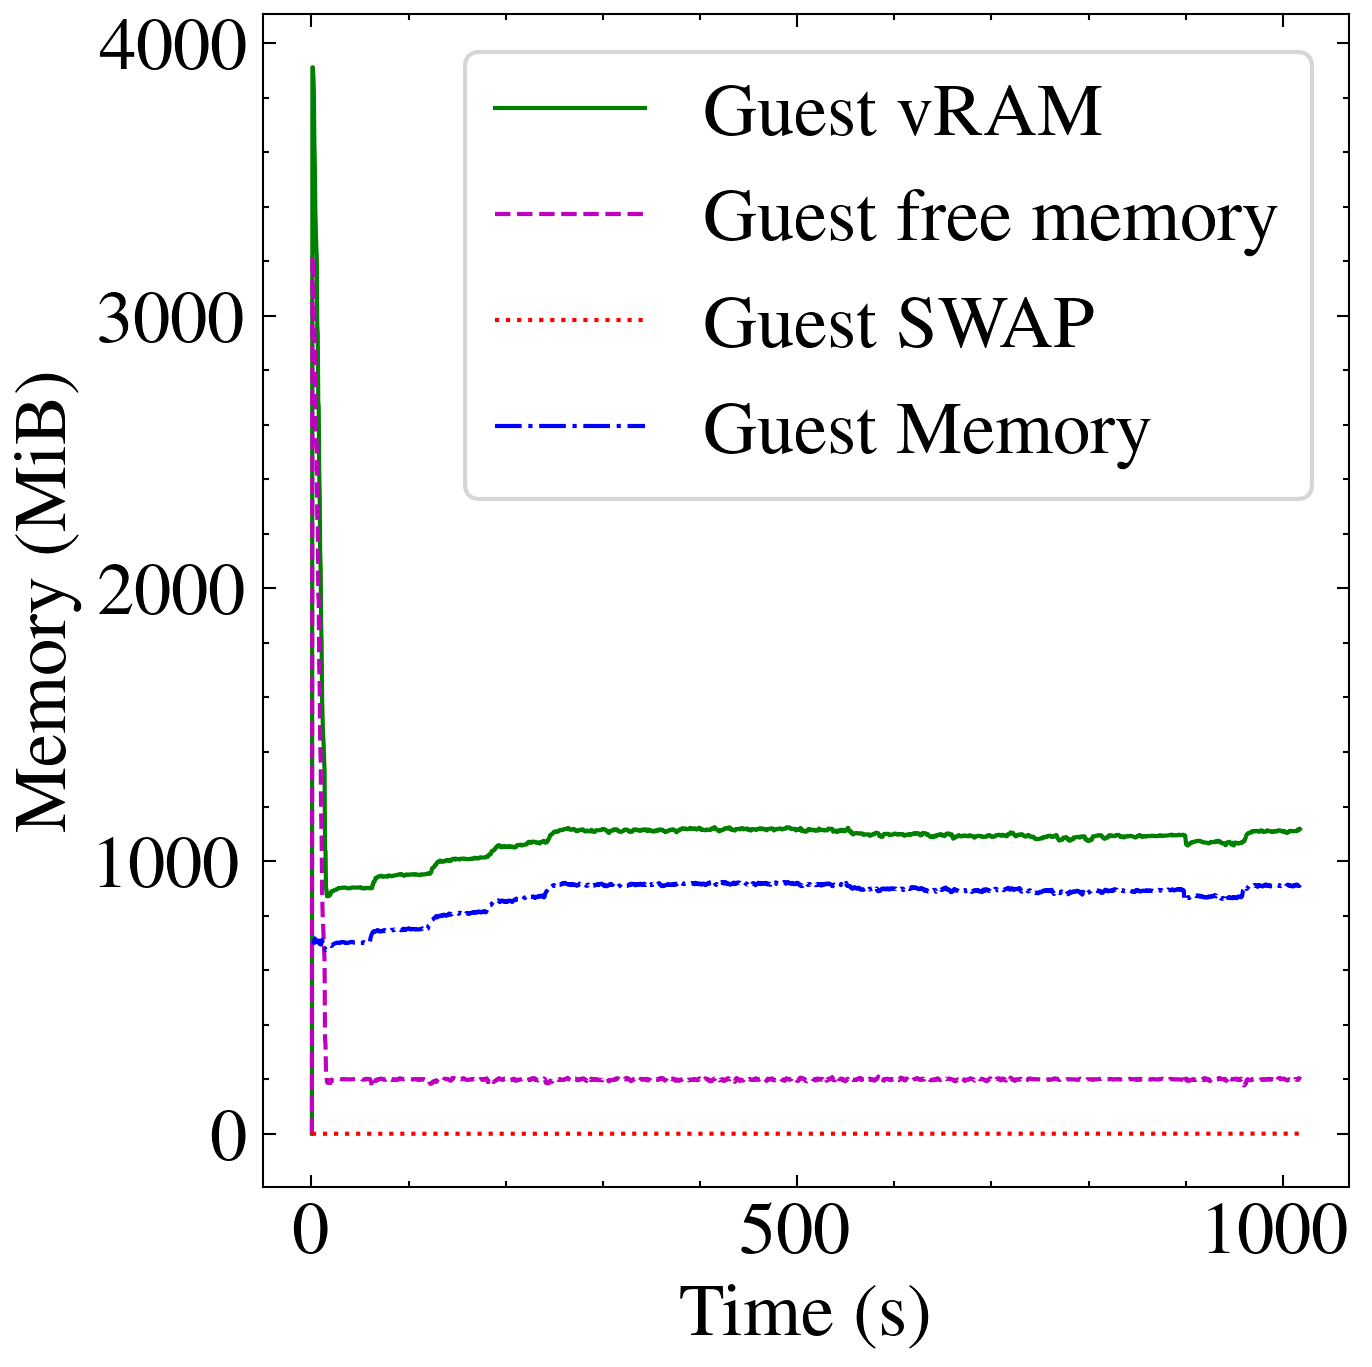

In [59]:
query = """
SELECT TIME, 
       MEDIAN("VIRSH AVAILABLE") AS "Guest vRAM",
       MEDIAN("VIRSH USABLE") AS "Guest free memory",
       MEDIAN("VIRSH SWAP OUT") AS "Guest SWAP",
       MEDIAN("VM MEMORY USAGE") AS "Guest Memory"
FROM stats
WHERE exp_name='balloon-pid-viewer-increase-double-longer-par20'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["Guest vRAM"]/(1024), label="Guest vRAM", color='g', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest free memory"]/(1024), label="Guest free memory", color='m', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest SWAP"]/(1024), label="Guest SWAP", color='r', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest Memory"], label="Guest Memory", color='b', linewidth=1)
    
ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')

ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/ballon_memory.pdf', bbox_inches='tight', dpi=300)
plt.show()

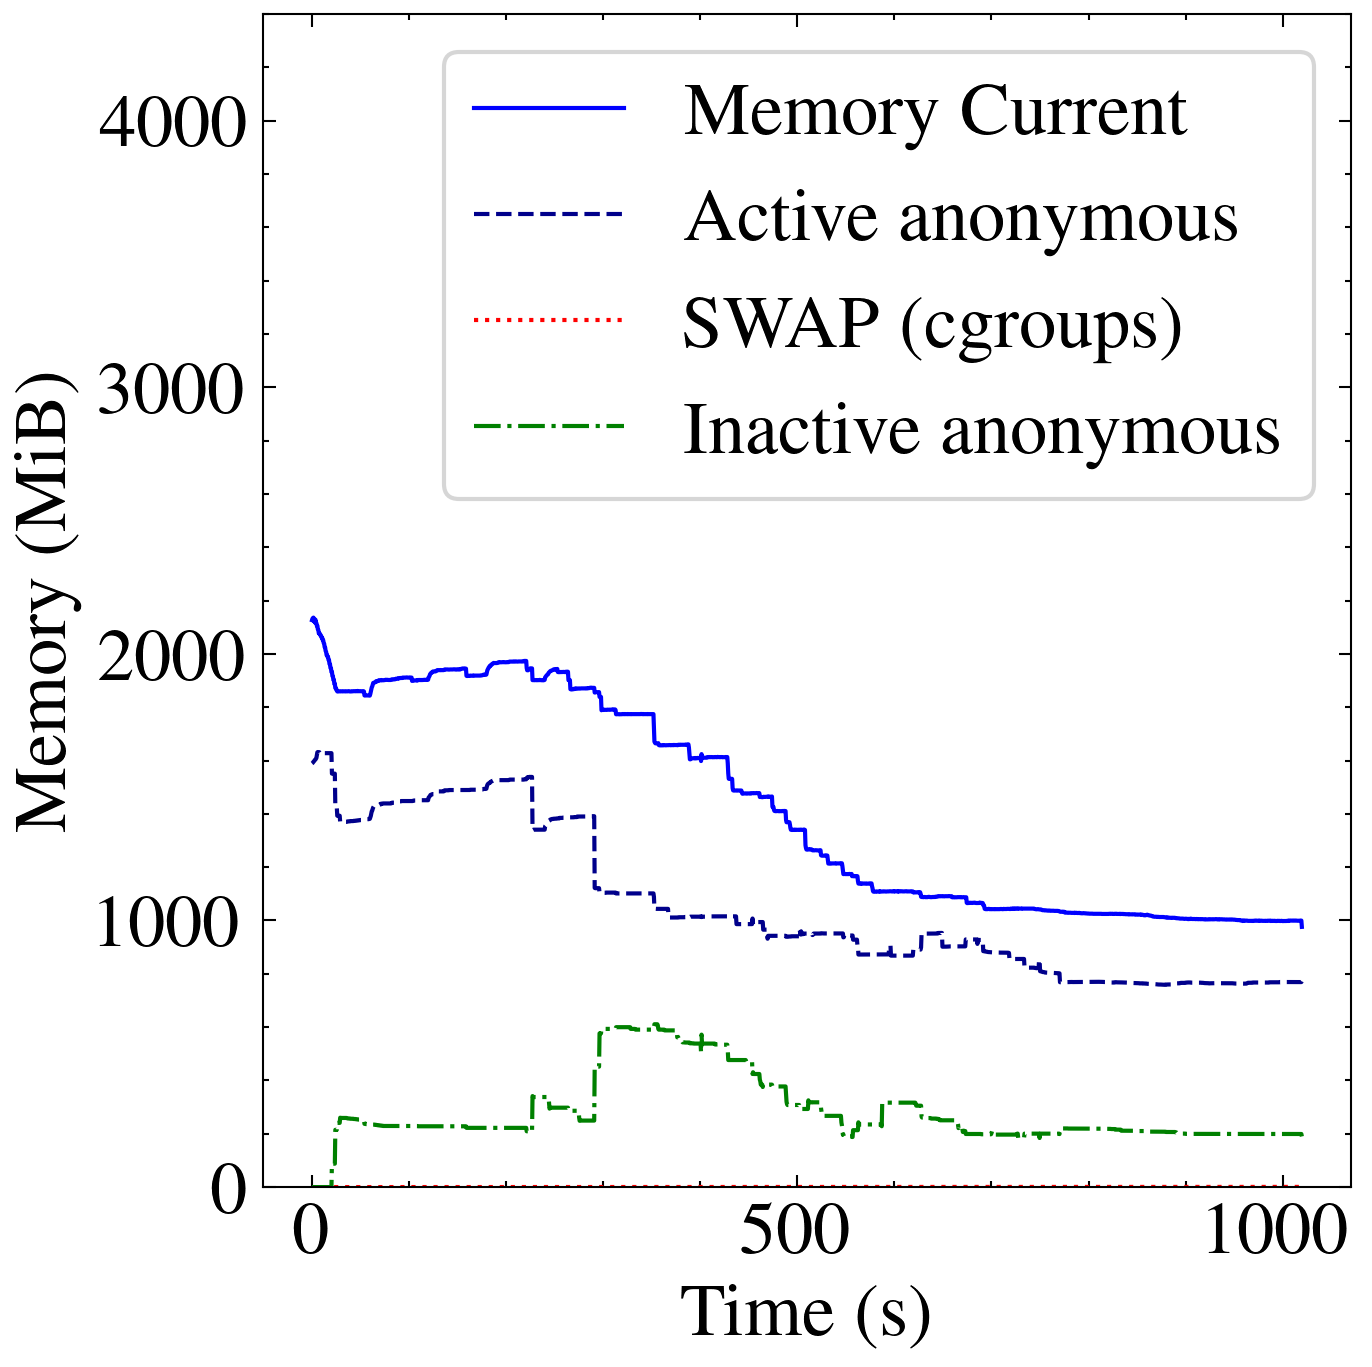

In [56]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY CURRENT") AS "ram",
       MEDIAN("ACTIVE ANON") AS "active",
       MEDIAN("SWAP CURRENT") AS "swap",
       MEDIAN("INACTIVE ANON") AS "inactive"
FROM cgroup_stats
WHERE exp_name='cgroups-regul-stddev-30-viewer-double-increase-par20'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["ram"], label="Memory Current", color='b')
ax.plot(df["TIME"]/1000, df["active"]/(1024*1024), label="Active anonymous", color='darkblue')
ax.plot(df["TIME"]/1000, df["swap"]/(1024), label="SWAP (cgroups)", color='r')
ax.plot(df["TIME"]/1000, df["inactive"]/(1024*1024), label="Inactive anonymous", color='g')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,4400)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/cgroup_memory.pdf', bbox_inches='tight', dpi=300)
plt.show()